# Notebook 3: Instability Regimes
**On the Stability of Risk Parity Allocations under Covariance Perturbations**

---

This notebook characterises *when* $C(\Sigma)$ becomes large — i.e., when small covariance
perturbations produce disproportionate allocation instability.

**Main findings:**
1. $C(\Sigma)$ grows with $\kappa(\Sigma)$ — ill-conditioned covariance matrices cause instability
2. Instability is amplified when $n/T$ is large (high dimension relative to sample)
3. A minimum sample size $T^*$ can be derived to keep expected weight perturbation below a threshold

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import matplotlib.gridspec as gridspec

from risk_parity import solve_risk_parity, stability_constant, condition_number, analytical_bound
from covariance import make_covariance, make_factor_covariance, estimation_error
from plotting import plot_weight_dispersion, savefig

rng = np.random.default_rng(42)

## 3.1  Heatmap: Weight Perturbation over (κ, T) Grid

We sweep over condition number $\kappa$ and sample size $T$,
recording empirical $\|\hat{w} - w^*\|$ at each cell.

In [2]:
n = 8
kappa_grid = np.logspace(0.5, 2.8, 14)  # ~3 to 600
T_grid = [50, 100, 200, 400, 800, 1600, 3200]
N_MC = 300

dispersion = np.zeros((len(kappa_grid), len(T_grid)))

for i, kappa in enumerate(kappa_grid):
    Sigma = make_covariance(n, kappa=kappa, seed=i)
    w_star, _ = solve_risk_parity(Sigma)
    for j, T in enumerate(T_grid):
        errs = []
        for s in range(N_MC):
            E, _ = estimation_error(Sigma, T, seed=s)
            Sigma_hat = Sigma + E
            if np.linalg.eigvalsh(Sigma_hat)[0] > 0:
                w_hat, _ = solve_risk_parity(Sigma_hat)
                errs.append(norm(w_hat - w_star))
        dispersion[i, j] = np.mean(errs) if errs else np.nan

print('Grid sweep complete.')

Grid sweep complete.


Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig5_instability_heatmap.png


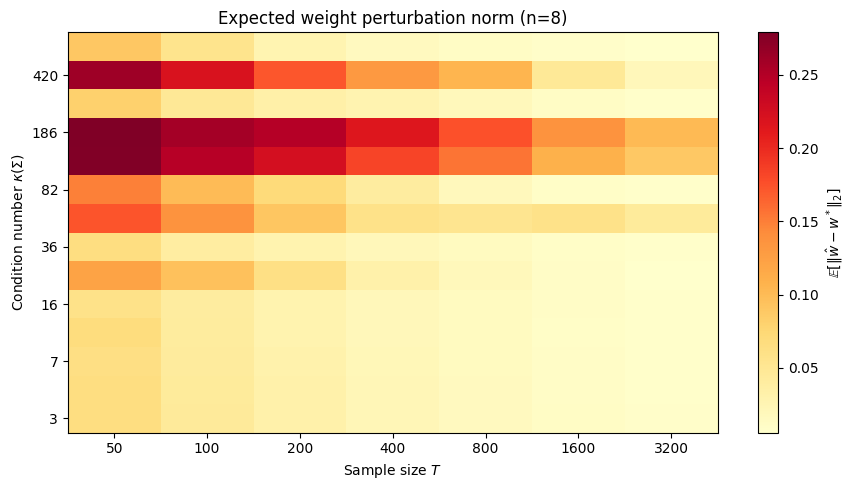

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(dispersion, aspect='auto', origin='lower', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label=r'$\mathbb{E}[\|\hat{w} - w^*\|_2]$')
ax.set_xticks(range(len(T_grid)))
ax.set_xticklabels(T_grid)
ax.set_yticks(range(0, len(kappa_grid), 2))
ax.set_yticklabels([f'{k:.0f}' for k in kappa_grid[::2]])
ax.set_xlabel('Sample size $T$')
ax.set_ylabel(r'Condition number $\kappa(\Sigma)$')
ax.set_title(f'Expected weight perturbation norm (n={n})')
plt.tight_layout()
savefig('fig5_instability_heatmap')
plt.show()

## 3.2  Instability Threshold: Minimum Sample Size T*

From the bound $\mathbb{E}[\|\hat{w} - w^*\|] \leq C(\Sigma) \sqrt{n/T}$, solving for $T$:

$$T^*(\epsilon) = \left\lceil \frac{n \cdot C(\Sigma)^2}{\epsilon^2} \right\rceil$$

This is the minimum sample size to guarantee expected weight error below $\epsilon$.

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig6_min_sample_size.png


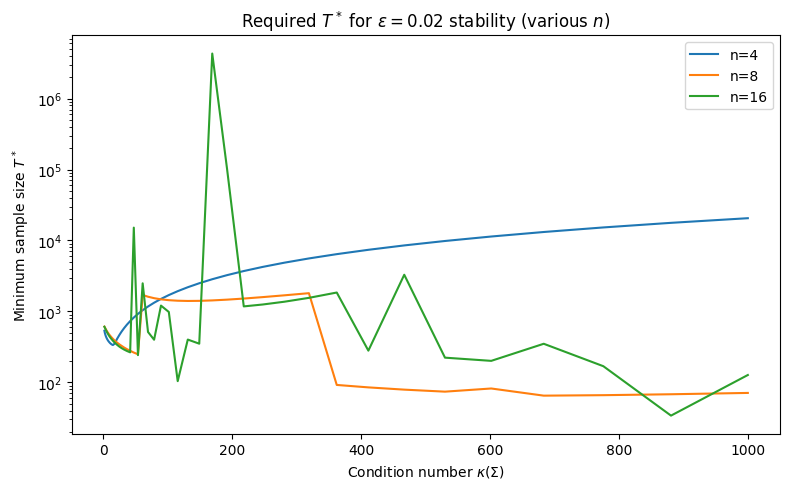

In [4]:
def min_sample_size(Sigma, epsilon):
    """Minimum T to guarantee E[||delta_w||] < epsilon."""
    n = Sigma.shape[0]
    w_star, _ = solve_risk_parity(Sigma)
    C, _, _ = stability_constant(w_star, Sigma)
    return int(np.ceil(n * C**2 / epsilon**2))


kappa_sweep = np.logspace(0.3, 3.0, 50)
n_vals = [4, 8, 16]
epsilon = 0.02  # 2% weight perturbation tolerance

plt.figure(figsize=(8, 5))
for n in n_vals:
    T_stars = []
    for kappa in kappa_sweep:
        Sigma = make_covariance(n, kappa=kappa, seed=42)
        T_stars.append(min_sample_size(Sigma, epsilon))
    plt.semilogy(kappa_sweep, T_stars, label=f'n={n}')

plt.xlabel(r'Condition number $\kappa(\Sigma)$')
plt.ylabel(r'Minimum sample size $T^*$')
plt.title(rf'Required $T^*$ for $\epsilon = {epsilon}$ stability (various $n$)')
plt.legend()
plt.tight_layout()
savefig('fig6_min_sample_size')
plt.show()

## 3.3  Factor Model: Near-Singular Covariance

In practice, equity covariance matrices are often generated by a small number of factors ($k \ll n$),
producing near-singular $\Sigma$ with very high $\kappa$. We test whether RP is stable under this structure.

In [5]:
n = 10
k_values = [1, 2, 3, 5, 8]  # number of factors
T = 250  # short sample, typical in finance
N_MC = 500

results = {'k': [], 'kappa': [], 'C': [], 'emp_error': []}

for k in k_values:
    Sigma = make_factor_covariance(n, k=k, idio_var=0.05, seed=42)
    w_star, _ = solve_risk_parity(Sigma)
    C, _, _ = stability_constant(w_star, Sigma)
    kappa = condition_number(Sigma)

    errs = []
    for s in range(N_MC):
        E, _ = estimation_error(Sigma, T, seed=s)
        Sigma_hat = Sigma + E
        if np.linalg.eigvalsh(Sigma_hat)[0] > 0:
            w_hat, _ = solve_risk_parity(Sigma_hat)
            errs.append(norm(w_hat - w_star))

    results['k'].append(k)
    results['kappa'].append(kappa)
    results['C'].append(C)
    results['emp_error'].append(np.mean(errs))

print(f'{"Factors k":>12} {"kappa":>12} {"C(Sigma)":>12} {"Emp error":>12}')
print('-' * 52)
for i in range(len(k_values)):
    print(f"{results['k'][i]:>12} {results['kappa'][i]:>12.1f} "
          f"{results['C'][i]:>12.4f} {results['emp_error'][i]:>12.6f}")

   Factors k        kappa     C(Sigma)    Emp error
----------------------------------------------------
           1        317.8      40.9872     0.157606
           2        174.2       7.3820     0.279780
           3        119.8       4.8806     0.061730
           5         83.2      13.1148     0.306326
           8         61.4       6.6045     0.206023


Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig7_factor_instability.png


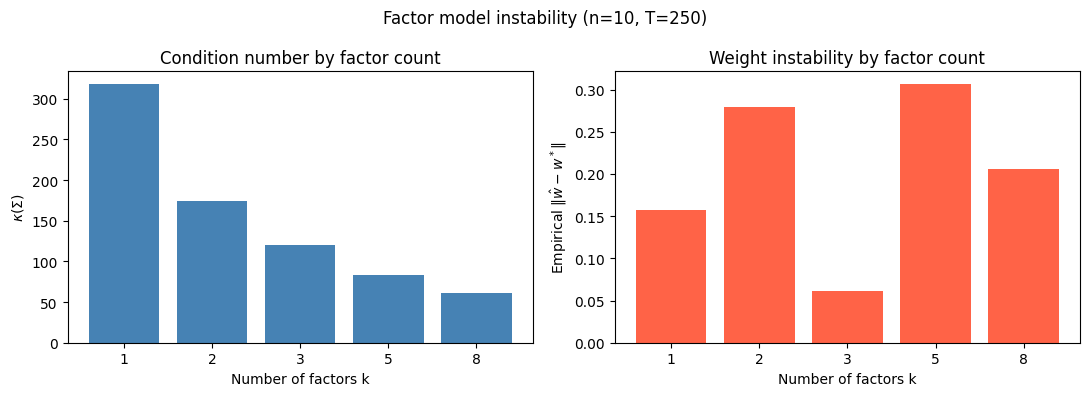

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar([str(k) for k in results['k']], results['kappa'], color='steelblue')
ax1.set_xlabel('Number of factors k')
ax1.set_ylabel(r'$\kappa(\Sigma)$')
ax1.set_title('Condition number by factor count')

ax2.bar([str(k) for k in results['k']], results['emp_error'], color='tomato')
ax2.set_xlabel('Number of factors k')
ax2.set_ylabel(r'Empirical $\|\hat{w} - w^*\|$')
ax2.set_title('Weight instability by factor count')

plt.suptitle(f'Factor model instability (n={n}, T={T})', fontsize=12)
plt.tight_layout()
savefig('fig7_factor_instability')
plt.show()